# K-Means Clustering

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/01-unsupervised-learning/k-means/notes.ipynb)

*Unsupervised learning — grouping data that has no labels to begin with.*


## 1. What is K-Means, intuitively?

Here's a scatter plot with nothing on it — no colors, no labels, no legend. Just dots. Take a second and actually
look at it before reading past the plot.


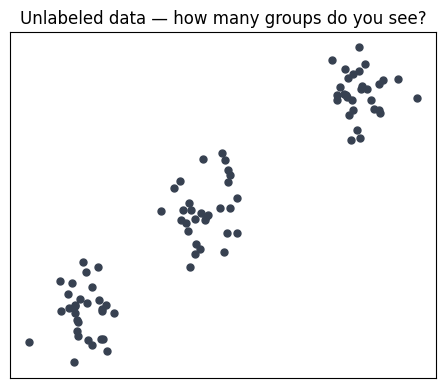

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(0)
X_preview, _ = make_blobs(n_samples=90, centers=3, cluster_std=0.9, random_state=3)

plt.figure(figsize=(5.5, 4.5))
plt.scatter(X_preview[:, 0], X_preview[:, 1], s=25, color="#374151")
plt.title("Unlabeled data — how many groups do you see?")
plt.xticks([]); plt.yticks([])
plt.show()

**No code needed for this part — just look and guess:** how many groups would you circle, and where would you
put the center of each circle? Almost everyone says "3," and almost everyone plants each center somewhere near the
*middle* of a blob without being told to. That instinct — points that sit close together belong together, and each
group has a natural center — is basically the whole idea. K-Means doesn't invent a new way of thinking about this;
it just takes the instinct you already have and turns it into something a computer can repeat exactly, on data with
way more than two dimensions where you can't just eyeball it anymore.

So, what is clustering exactly? It's grouping data points so that points in the same group are more similar to
each other than to points in other groups — using only the raw features, with no labels handed to you. That "no
labels" part is the whole reason this is a different kind of problem. A lot of real data just doesn't come with a
correct-answer column: nobody's tagged which customers are "big spenders," nobody's labeled which songs belong in
the same mood playlist. You have to find the groups yourself, and that's what clustering exists for.

The **K** in K-Means is just the number of groups you're telling it to find, decided upfront — "go find me 3
groups" means K=3.

A few other places this same idea shows up, once you start noticing it:
- Playlists — grouping listeners with similar taste
- Watch history — grouping viewers by streaming behavior
- Photo albums — automatically grouping photos of the same person
- Image compression — grouping similar pixel colors
- Customer segmentation — grouping customers by behavior, without anyone hand-labeling them first


**Quick check before moving on**

> If K-Means groups points by how "close" they are, what does it need to be able to do before it can group
> anything at all?
>
> *(Sit with that for a second — the next section is exactly the answer.)*


## 2. Measuring "similarity" with distance

"Close" isn't a real number until you define it. K-Means picks the most natural definition — straight-line
distance — and gives it a name: **Euclidean distance**.

$$
d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + \cdots + (p_n - q_n)^2}
$$

That's just `np.linalg.norm(p - q)` for two points `p` and `q`. Nothing fancier than the distance formula from
school geometry, extended to however many features you have. But it's the one building block everything else in
this algorithm stands on.


**Try it by hand first:** three customers, described by two features — `visits_per_month` and
`avg_order_value`.

| Customer | visits_per_month | avg_order_value |
|---|---|---|
| A | 2 | 10 |
| B | 3 | 11 |
| C | 8 | 40 |

Before running anything — does A feel closer to B, or closer to C? Work out $d(A, B)$ on paper:
$\sqrt{(2-3)^2 + (10-11)^2} = \sqrt{1 + 1} = \sqrt{2} \approx 1.41$. Now see if the code agrees with your gut.


In [2]:
def euclidean_distance(p, q):
    """Straight-line distance between two points (any number of dimensions)."""
    return np.linalg.norm(np.array(p) - np.array(q))

A, B, C = (2, 10), (3, 11), (8, 40)

print("d(A, B) =", euclidean_distance(A, B))
print("d(A, C) =", euclidean_distance(A, C))
print("d(B, C) =", euclidean_distance(B, C))
# A and B come out close together; C sits far from both — matches the gut read.

d(A, B) = 1.4142135623730951
d(A, C) = 30.59411708155671
d(B, C) = 29.427877939124322


## 3. What makes a clustering good or bad

Hand the same unlabeled data to two different analysts and you can genuinely get two different groupings back —
and only one of them is actually good. So what makes one better than the other? Two ideas:

- **Intra-cluster distance** — how spread out the points are *inside* one group. Smaller is better: it means the
  group is tight and cohesive, not just a loose scatter someone drew a circle around.
- **Inter-cluster distance** — how far apart the groups are *from each other*. Bigger is better: it means the
  groups are actually distinct, not bleeding into one another.

A good clustering keeps the first one small and the second one large. K-Means directly optimizes the first half of
that — minimizing spread inside each cluster — and gives it a name: **Within-Cluster Sum of Squares**, or WCSS
(sometimes called *inertia*).

$$
WCSS = \sum_{i=1}^{k} \sum_{p \in C_i} \lVert p - \mu_i \rVert^2
$$

In words: take every point, measure its squared distance to its own cluster's center $\mu_i$, and add all of that
up. That single number is what K-Means is trying to make as small as possible.


## 4. Inventing & coding K-Means from scratch

Say you had to automate this grouping process yourself, with no algorithm to look up — just "write me the steps."
Chances are you'd land on something close to this:

1. **Initialize** — pick `k` starting center points (centroids), anywhere to begin with.
2. **Assign** — give every point to whichever centroid it's closest to.
3. **Update** — now that each centroid has a group of points, move it to the *middle* of that group.
4. **Repeat** — keep alternating assign and update until nothing changes anymore.

Why does the centroid move specifically to the *mean* of its group, and not, say, somewhere else? Because the mean
happens to be the one point that minimizes WCSS for a set of points — it's not a convenient guess, it's the exact
point the math says to move to, given what we're trying to minimize.


**Do one round yourself, on paper:** four points, and you're told to start with two centroids,
$C_1 = (1, 1)$ and $C_2 = (8, 8)$.

| Point | Coordinates |
|---|---|
| P1 | (1, 2) |
| P2 | (2, 1) |
| P3 | (7, 8) |
| P4 | (9, 7) |

**Assign:** which centroid is each point closer to? P1 and P2 are obviously near (1,1), P3 and P4 near (8,8) — so
P1, P2 go to $C_1$'s group, P3, P4 go to $C_2$'s group.

**Update:** move each centroid to the mean of its new group.
$C_1 \to \text{mean}((1,2),(2,1)) = (1.5,\ 1.5)$, and $C_2 \to \text{mean}((7,8),(9,7)) = (8,\ 7.5)$.

One round, done entirely by hand. Run it again with these new centroids and the assignments won't budge — that's
convergence. Everything below just automates this exact process and lets you watch it happen frame by frame.

**Quick check**

> Why does the update step move the centroid to the *mean* of its points, and not the *median*?
>
> The mean is specifically the point that minimizes WCSS — total squared distance from points to their center.
> The median minimizes a different quantity (sum of *absolute* distances), which isn't what K-Means is built to
> optimize. Swap in the median and you're no longer running K-Means, even if the rest of the loop looks the same.

Here's the from-scratch build, one piece at a time.


### 4.1 Initialize — pick starting centroids

In [3]:
def initialize_centroids(X, k, seed=100):
    """Randomly pick k data points to serve as the starting centroids."""
    rng = np.random.RandomState(seed)
    indices = rng.choice(len(X), size=k, replace=False)
    print("Indices:",indices)
    return X[indices].copy()

### 4.2 Assign — allocate every point to its nearest centroid

In [4]:
#Assignment of clusters to each datapoint
def assign_clusters(X, centroids):
    labels = []

    for point in X:
        # Calculate distance from this point to every centroid
        distances = []

        for centroid in centroids:
            distance = np.linalg.norm(point - centroid)
            distances.append(distance)

        # Assign the point to the nearest centroid
        labels.append(np.argmin(distances))

    return np.array(labels)

### 4.3 Update — move each centroid to the mean of its assigned points

In [5]:
def update_centroids(X, labels, centroids):
    new_centroids = []

    for i in range(len(centroids)):
        cluster = X[labels == i]

        if len(cluster) == 0:
            # keep old centroid
            new_centroids.append(centroids[i])
        else:
            new_centroids.append(cluster.mean(axis=0))

    return np.array(new_centroids)
print("Building blocks defined.")

Building blocks defined.


### 4.4 Fit — chain initialize / assign / update into the full loop

This version also plots every iteration side by side, so instead of just trusting it converges, you actually watch it happen.

In [6]:
def fit(X, k, n_iters=100, seed=42, plot_every=False):
    centroids = initialize_centroids(X, k, seed)

    if plot_every:
        plot_states = [] # List to store (labels, new_centroids, iteration_number) tuples

    for i in range(n_iters):
        # Store centroids before assignment step to match original convergence check logic
        centroids_before_assignment = centroids.copy()

        # Step 1: Assign points
        labels = assign_clusters(X, centroids_before_assignment)

        # Step 2: Compute new centroids
        new_centroids = update_centroids(X, labels, centroids_before_assignment)

        # Store the state for plotting if plot_every is True
        if plot_every:
            # We want to plot `labels` (assigned by centroids_before_assignment) and `new_centroids`
            plot_states.append((labels.copy(), new_centroids.copy(), i + 1))

        # Check convergence
        if np.linalg.norm(new_centroids - centroids_before_assignment) < 1e-5:
            print(f"Converged after {i+1} iterations.")
            centroids = new_centroids # Update `centroids` for the function's return value
            break # Exit the loop, the last state is already in plot_states

        centroids = new_centroids # Update `centroids` for the next iteration

    # Final assignment of labels after the loop, based on the final `centroids`
    labels = assign_clusters(X, centroids)

    # Now, generate all plots horizontally if plot_every is True
    if plot_every and plot_states:
        num_plots = len(plot_states)
        # Ensure that if only one plot is generated, axes is still an iterable (1D array)
        fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4), squeeze=False)
        axes = axes.flatten()

        for idx, (iter_labels, iter_centroids, iter_num) in enumerate(plot_states):
            ax = axes[idx]
            for j in range(k):
                ax.scatter(
                    X[iter_labels == j, 0],
                    X[iter_labels == j, 1],
                    s=20,
                    label=f"Cluster {j}" if idx == 0 else "" # Label only for the first subplot
                )
            ax.scatter(
                iter_centroids[:, 0],
                iter_centroids[:, 1],
                marker="X",
                s=180,
                c="black",
                label="Centroids" if idx == 0 else "" # Label only for the first subplot
            )
            ax.set_title(f"Iteration {iter_num}")
            ax.set_xticks([])
            ax.set_yticks([])
            if idx == 0:
                ax.legend(loc='lower right') # Legend only for the first subplot
        plt.tight_layout()
        plt.show()

    return centroids, labels

### 4.5 Run it

Indices: [128  18 130 105]
Converged after 4 iterations.


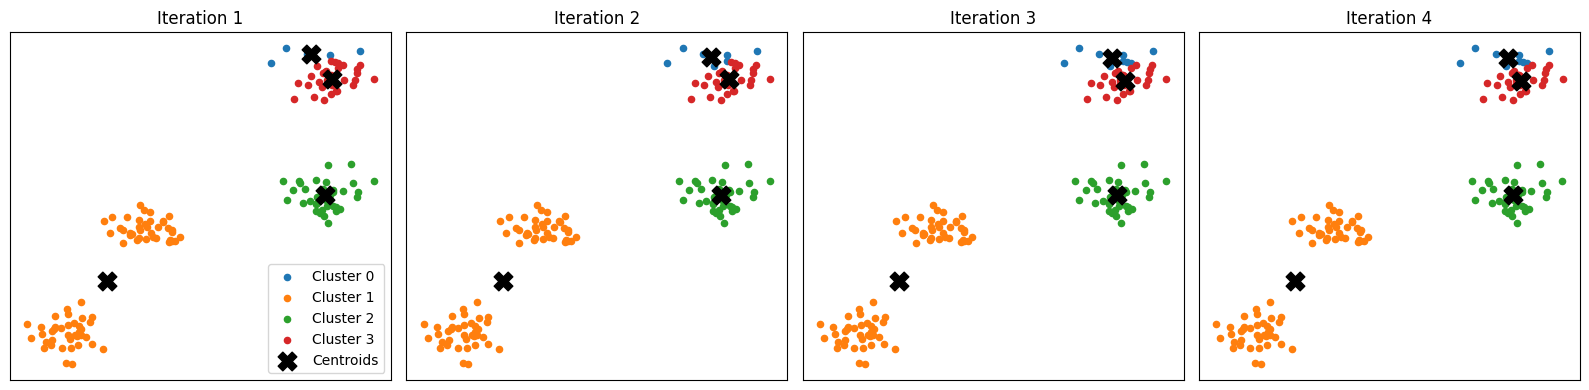

In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Run our from-scratch K-Means
X_scratch, _ = make_blobs(
    n_samples=150,
    centers=4,
    cluster_std=0.9,
    random_state=8
)
centroids_scratch, labels_scratch = fit(
    X_scratch,
    k=4,
    seed=4,
    plot_every=True
)

### 4.6 Sanity check against scikit-learn
Same data, same logic — just confirming the from-scratch version lands in the same place as the real library.

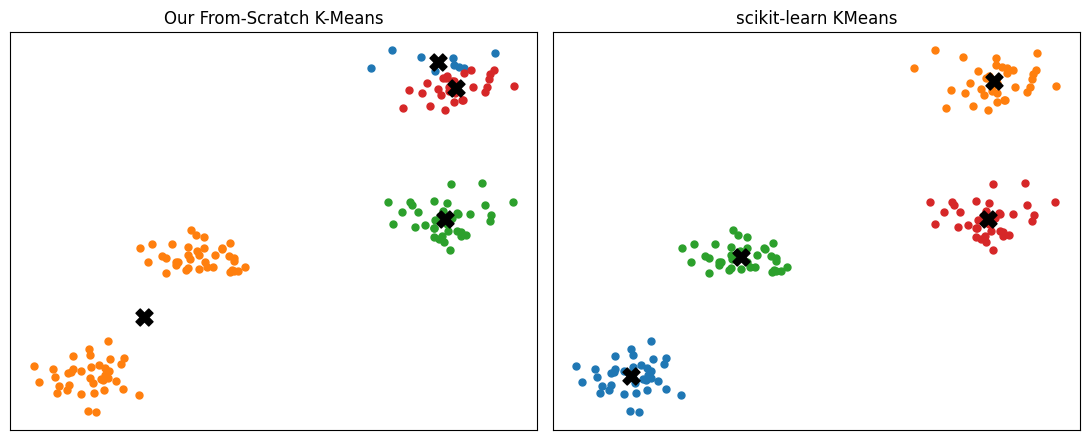

In [8]:
from sklearn.cluster import KMeans

# Compare our from-scratch implementation against scikit-learn's KMeans
sk_model = KMeans(
    n_clusters=4,
    init="random",
    n_init=1,
    random_state=42
)
sk_labels = sk_model.fit_predict(X_scratch)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for j in range(4):
    axes[0].scatter(X_scratch[labels_scratch == j, 0], X_scratch[labels_scratch == j, 1], s=25)
    axes[1].scatter(X_scratch[sk_labels == j, 0], X_scratch[sk_labels == j, 1], s=25)
axes[0].scatter(centroids_scratch[:, 0], centroids_scratch[:, 1], marker='X', s=150, c='black')
axes[1].scatter(sk_model.cluster_centers_[:, 0], sk_model.cluster_centers_[:, 1], marker='X', s=150, c='black')
axes[0].set_title("Our From-Scratch K-Means")
axes[1].set_title("scikit-learn KMeans")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 5. Why the starting point matters: local minima

Here's something that trips people up the first time they see it: run K-Means twice on the *exact same data*, with
the *exact same K*, and you can get two different final groupings back — just because the random starting
centroids were different.


### 5.1 Why this happens

That's not a bug, it's baked into how the algorithm works:

- K-Means only ever moves centroids *downhill* — every assign/update round can only decrease WCSS or leave it
  unchanged, never increase it.
- That guarantees convergence, but it also means the algorithm never checks whether a completely different
  arrangement of clusters, elsewhere, would've scored better.
- It just walks downhill from wherever it started and stops the moment nothing local helps anymore.

That stopping point is a **local minimum** — a configuration where no small change improves things, even though a
bigger, different rearrangement might have given a lower WCSS overall (the **global minimum**). K-Means can't tell
the two apart, and has no way to escape a local minimum once it's landed in one.


### 5.2 The picture to hold onto

Think of WCSS as a landscape with several valleys of different depths. Wherever your random starting centroids
happen to drop you, you slide to the bottom of *that* valley and stop — even if a deeper valley exists somewhere
else entirely. Different starting points can drop you into different valleys, which is exactly why two runs on the
same data can converge to two different answers.


### 5.3 What we actually do about it

Not fix it exactly — there's no way to *guarantee* the global minimum without checking every possible arrangement,
which is computationally out of reach. But two practical habits make landing in a bad valley much less likely:

- **Run it more than once, keep the best.** Try several different random starting points, run K-Means to
  convergence each time, and keep whichever run ended with the *lowest* WCSS. This is exactly what `n_init` in
  scikit-learn does — `n_init=10` means "try 10 different random starts, keep the winner." More attempts means a
  better chance at least one lands in a deep valley.
- **Start smarter instead of purely randomly.** `k-means++` (scikit-learn's default `init`) doesn't pick starting
  centroids uniformly at random — it deliberately spreads them out, so they're more likely to start near
  genuinely different parts of the data instead of two centroids accidentally landing close together. A better
  starting spread means a better chance of reaching a good valley in the first place.

In practice, the two get combined: `KMeans(n_clusters=k, init="k-means++", n_init=10)` — smart starting points,
tried several times, best result kept. That's also why the "sanity check" cell above deliberately used
`init="random", n_init=1` instead of the defaults — so the from-scratch and library versions could be compared
doing the same bare-bones thing side by side, without either getting real help from better initialization.


In [9]:
# Same data, but now let scikit-learn actually try to avoid a bad local minimum:
# k-means++ initialization, run 10 times, keep the best.
sk_model_robust = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=42)
sk_labels_robust = sk_model_robust.fit_predict(X_scratch)

print("Single random start, WCSS  :", sk_model.inertia_)
print("k-means++, best of 10 runs :", sk_model_robust.inertia_)
# The second number should be the same or lower — never worse — since it's picking the best of more attempts.

Single random start, WCSS  : 264.39310635808386
k-means++, best of 10 runs : 264.39310635808386


## 6. Summary — revision cheat sheet

**What it is:** an unsupervised algorithm that groups `n` points into `k` clusters by nearest centroid — for data
that has no labels, where the whole point is discovering structure rather than predicting a known answer.

**Core intuition:** look at unlabeled points and you naturally spot groups, each with an obvious center. K-Means
automates exactly that: pick centers, assign every point to its nearest one, move each center to the middle of its
group, repeat until nothing moves.

**Core definitions:**
- *Euclidean distance* — $d(p,q) = \sqrt{\sum (p_i - q_i)^2}$ — the "closeness" metric K-Means uses.
- *Intra-cluster distance* — spread within a cluster (want small).
- *Inter-cluster distance* — separation between clusters (want large).
- *WCSS (inertia)* — $\sum_i \sum_{p \in C_i} \lVert p - \mu_i \rVert^2$ — total squared distance from points to
  their own centroid; this is the number K-Means minimizes.

**The algorithm (Lloyd's algorithm):**
1. Initialize — pick k starting centroids.
2. Assign — each point joins its nearest centroid.
3. Update — each centroid moves to the mean of its assigned points (the mean specifically, because it's what
   minimizes WCSS — not the median, not an arbitrary choice).
4. Repeat 2–3 until centroids stop moving (convergence).

**By-hand example worth remembering:** points near (1,1) and points near (8,8), starting centroids at those same
spots → one assign-update round already lands the centroids right at the true cluster means.

**Local minima — the thing to actually remember:** K-Means only ever moves downhill and stops at the first point
where nothing local helps, which isn't necessarily the best possible clustering overall. Two different random
starts can converge to two different answers. The practical fix: use `k-means++` initialization (spreads starting
centroids out sensibly instead of pure random) and `n_init > 1` (run several times, keep the lowest-WCSS result) —
`KMeans(init="k-means++", n_init=10)` rather than a single plain random start.

**Not yet covered (coming in later sessions):** how to choose K when you don't already know it (elbow method,
silhouette score), the full applied customer-segmentation pipeline with feature scaling, and other limitations of
K-Means beyond initialization (non-spherical clusters, outlier sensitivity). These will get their own notes once
covered in class.
